# 05 — Modelo preditivo e URA do 190

_Notebook do projeto **crime-sp-ml**. Reaproveita os módulos em `src/`._

In [1]:
import sys, pathlib
from IPython.display import Image, IFrame, display, Markdown
ROOT = pathlib.Path.cwd()
while not (ROOT/'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))
FIG = ROOT/'reports'/'figures'; MAPS = ROOT/'reports'/'maps'; REP = ROOT/'reports'
print('Projeto:', ROOT.name)

Projeto: crime-sp-ml


Modelo supervisionado (`src/modeling.py`) e camada de aplicação (`src/ura_ranking.py`). Entrada: `lat, lon, hora` → ranking de crimes.

In [2]:
import json, pandas as pd
m = json.load(open(REP/'model_metrics.json', encoding='utf-8'))
print('melhor modelo:', m['melhor_modelo'])
pd.DataFrame(m['modelos']).T[['accuracy','balanced_accuracy','f1_macro','top2_accuracy','top3_accuracy']]

melhor modelo: random_forest


,accuracy,balanced_accuracy,f1_macro,top2_accuracy,top3_accuracy
dummy_most_frequent,0.361766,0.050000,0.026566,0.374457,0.375926
dummy_prior,0.361766,0.050000,0.026566,0.695095,0.811884
logistic_regression,0.404273,0.057866,0.047374,0.694821,0.813415
random_forest,0.456702,0.070970,0.064575,0.713902,0.827491
hist_gradient_boosting,0.442529,0.070818,0.066844,0.704241,0.818767
hist_gradient_boosting_balanced,0.153408,0.162901,0.063604,0.268721,0.369719


### Matriz de confusão (melhor modelo)

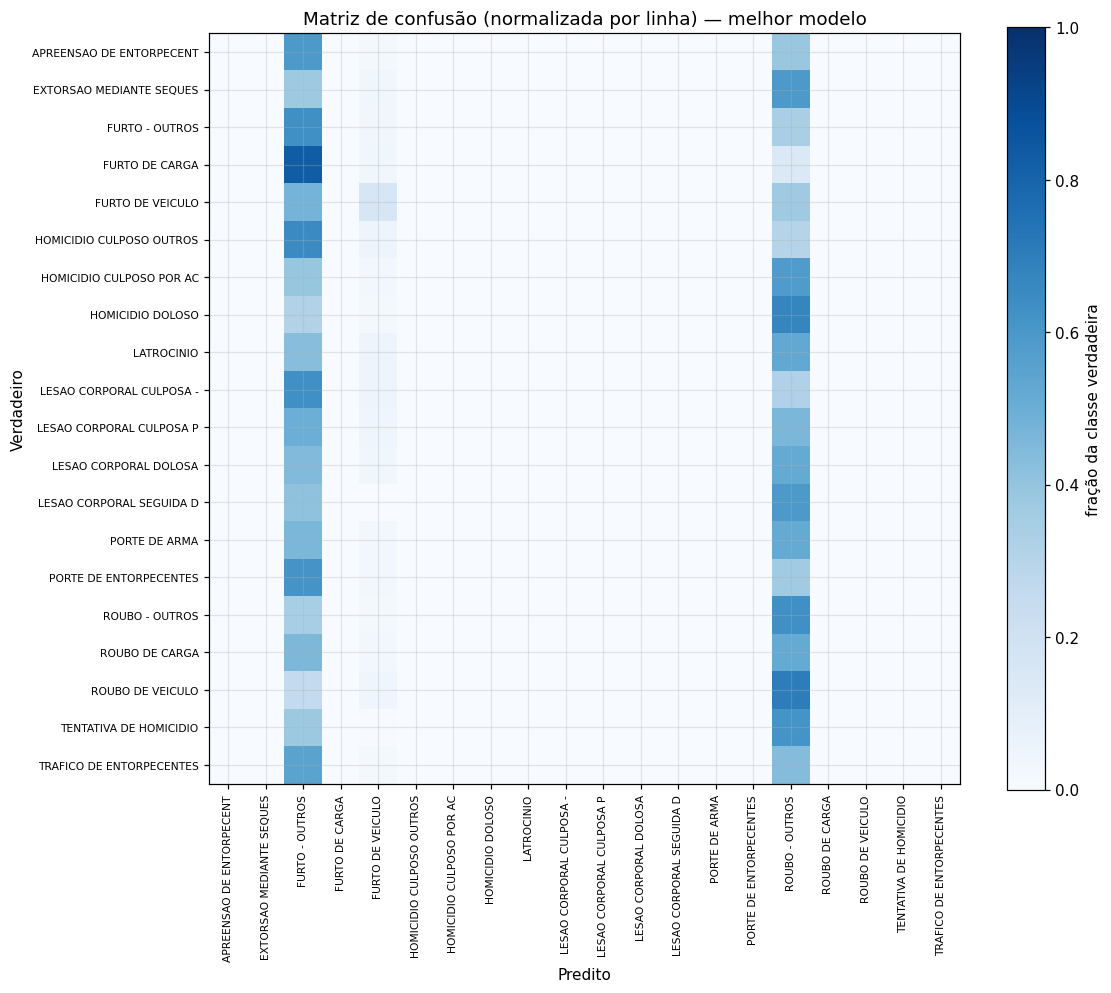

In [3]:
display(Image(filename=str(FIG/'confusion_matrix.png')))

### Ranking de crimes prováveis por local/horário

In [4]:
import ura_ranking as ura
casos = {'Av. Paulista 19h':(-23.5613,-46.6558,19),
         'Centro 3h':(-23.5505,-46.6333,3),
         'Zona Leste 8h':(-23.5487,-46.4583,8)}
for nome,(lat,lon,h) in casos.items():
    print('##', nome)
    for r in ura.predict_top_crimes(lat,lon,h,top_k=3):
        print('   {}. {} -> {:.1%}'.format(r['rank'], r['crime'], r['probabilidade']))

## Av. Paulista 19h


   1. ROUBO - OUTROS -> 46.8%
   2. FURTO - OUTROS -> 39.1%
   3. FURTO DE VEICULO -> 8.0%
## Centro 3h
   1. FURTO - OUTROS -> 43.5%
   2. ROUBO - OUTROS -> 43.0%
   3. LESAO CORPORAL DOLOSA -> 5.4%
## Zona Leste 8h
   1. FURTO - OUTROS -> 26.8%
   2. FURTO DE VEICULO -> 26.6%
   3. ROUBO - OUTROS -> 25.4%


### Texto de menu da URA (no máx. 2 crimes + atendente)

In [5]:
for nome,(lat,lon,h) in {'Av. Paulista 19h':(-23.5613,-46.6558,19),
                          'Zona Sul 21h':(-23.6680,-46.7082,21)}.items():
    print(nome, '->', ura.gerar_opcoes_ura(lat,lon,h))

Av. Paulista 19h -> Polícia Militar de São Paulo, 190. Para agilizar seu atendimento, selecione o tipo de ocorrência: 1. Roubo. 2. Furto. 3. Falar com atendente.
Zona Sul 21h -> Polícia Militar de São Paulo, 190. Para agilizar seu atendimento, selecione o tipo de ocorrência: 1. Roubo. 2. Furto. 3. Falar com atendente.


**Ética:** protótipo acadêmico de ORDENAÇÃO de opções; não decide, não substitui o atendente, e sempre oferece 'falar com atendente'.